# Notebook 08 — Preprocessing (Phase A, part 2): the URH

**Goal.** Build the **URH** (Hydrological Response Units) = every combination of **soil group × land-cover class**, and
compute, **for each minibacia, the area fraction of each URH**. This is the table the MGB water balance runs on
(one balance per URH, weighted by its fraction).

Pure Python (`rasterio` + `pyflwdir`), no QGIS. We reuse the minibacias from notebook 07, add **land cover** (ESA
WorldCover) and **soils** (**IGAC** field survey — the official 1:100 000 Colombian soil map — with **SoilGrids** only as gap-fill), and cross them.

Chain: **minibacias → land-cover classes → soil groups → URH = soil × land → fractions per minibacia**.

> **Status (added 2026-08-19) — this is the PRODUCTION URH notebook.** `data/processed/urh_fractions.csv`, written in step 4 below, is the file the water balance (`src/mgb_hydrology.py`) and the sediment engine (`src/mgb_sediment.py`) actually read, and the URH id convention defined in step 4 — `URH = soil_family·10 + land_class` — is the one hard-coded at `src/mgb_hydrology.py`:191 and `src/mgb_sediment.py`:712. `notebooks/02_urh.ipynb` is a 6×6 didactic toy that teaches a **different** id formula and writes no files; `notebooks/05_landcover_soils_reclass.ipynb` is a 30 m lower-Magdalena prototype. Neither feeds the model, yet `docs/03` and `docs/04` still send readers to the toy for the production layer — read this notebook instead. The grid loaded in step 1 is **not** a preview awaiting replacement: the 1500×705 / 8,672-minibacia discretisation is the adopted Phase A discretisation and every Phase B and Phase C result stands on it.

## Parameters & reclassification schemes

| Parameter | Meaning | Value |
|-----------|---------|-------|
| `SCALE` | DEM/working-grid down-sampling (1 = full 90 m) | ~~`8` preview~~ → **`8` — the adopted grid, not a preview; also inert here** |
| `STREAM_THR`, `N_TARGET`, `OUTLET` | ~~as in notebook 07 (to rebuild the minibacias)~~ **inert here — never read by any code cell** | ~~200 · 8000 · Calamar~~ → notebook 07 actually ran **100 · 12000 · Calamar** |

**Land cover → 8 hydrological classes** (ESA WorldCover codes on the left):
Forest(10) · Shrub(20) · Grassland(30) · Cropland(40) · Urban(50) · Bare(60,70,100) · Water(80) · Wetland(90,95).

**Soil → 3 texture families** (Coarse / Medium / Fine) read directly from the **IGAC** field survey (the free-text
`CARACTERÍSTICAS_SUELOS` description of every soil-map polygon), with **SoilGrids** used only where IGAC is missing.
*(The same IGAC description also carries soil **depth** and **drainage** — with texture, these give W<sub>m</sub> and K
directly in notebook 09, so SoilGrids is no longer needed for the parameters. `build_soil_layer.py` writes all three
rasters: `soil_family_igac.tif`, `soil_depth_igac.tif`, `soil_drainage_igac.tif`.)*

> **About the two struck values above (added 2026-08-19) — one was wrong, one was harmless, and it is worth saying which.** (1) **Wrong:** notebook 07 did not run at `STREAM_THR = 200` / `N_TARGET = 8000`; its executed parameter line reads `SCALE=8  STREAM_THR=100 km2  N_TARGET=12000`, and it realised **8,672** minibacias. (2) **Harmless:** `SCALE`, `STREAM_THR`, `N_TARGET` and `OUTLET` are assigned in the next code cell and then **never read by any later cell** — the grid is not rebuilt here, it is loaded from `data/processed/minibacias.tif` in step 1. The DEM tar is extracted and never opened, and `pyflwdir` is imported and never used. So the mismatch changed no number in this notebook; it only misinforms the reader about how the grid was made.

In [1]:
import glob, zipfile, tarfile, tempfile
from pathlib import Path
import numpy as np, pandas as pd, rasterio
from rasterio.enums import Resampling as RS
from rasterio.warp import reproject, Resampling
from affine import Affine
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches, matplotlib.pyplot as plt
import pyflwdir
%matplotlib inline

# ---------------- PARAMETERS ----------------
SCALE=8; STREAM_THR=200; N_TARGET=8000; OUTLET=(-74.915,10.243)
# --------------------------------------------
REPO=None
for b in [Path.cwd()]+list(Path.cwd().parents):
    if (b/'data'/'raw').exists(): REPO=b; break
REPO=REPO or Path.cwd()
# DEM
tar=sorted(glob.glob(str(REPO/'data'/'raw'/'dem'/'rasters_COP90*Corr*.tar.gz')))
demtif=Path(tempfile.gettempdir())/'output_hh.tif'
if tar and not demtif.exists():
    with tarfile.open(tar[0]) as t: t.extract('output_hh.tif', path=demtif.parent)
LCZIP=glob.glob(str(REPO/'data'/'raw'/'landcover'/'*.zip'))[0]
SOIL=str(REPO/'data'/'raw'/'soils')
print('DEM', demtif.exists(), '| land cover zip ok | soils', len(glob.glob(SOIL+"/soilgrids_*.tif")),'rasters')

DEM True | land cover zip ok | soils 5 rasters


## Step 1 — Load the minibacias from notebook 07 (no re-delineation)

Notebook 07 already exported the minibacia grid to `data/processed/minibacias.tif`. We just **load** it here — the
grid (`subs`, transform, extent) is inherited, so 07 and 08 are guaranteed to be on the **same grid**. Run notebook 07
first if the file is missing.

In [2]:
mb_path = REPO/'data'/'processed'/'minibacias.tif'
assert mb_path.exists(), "Run notebook 07 first (it exports data/processed/minibacias.tif)"
with rasterio.open(mb_path) as ds:
    subs = ds.read(1)
    dst_tr = ds.transform; H, W = ds.height, ds.width
    b = ds.bounds; extent=[b.left,b.right,b.bottom,b.top]
basmask = subs > 0
n_mini = int(np.unique(subs[subs>0]).size)
print(f'loaded minibacias.tif: {H}x{W} grid | {n_mini} minibacias | domain lon[{b.left:.1f},{b.right:.1f}] lat[{b.bottom:.1f},{b.top:.1f}]')

loaded minibacias.tif: 1500x705 grid | 8672 minibacias | domain lon[-77.0,-72.3] lat[1.4,11.4]


## Step 2 — Land cover → 8 hydrological classes

We mosaic the ESA WorldCover tiles (read from the zip, down-sampled with **majority** resampling — the data is
categorical), then reclassify the 11 WorldCover codes into 8 model classes.

**Reduction criterion — hydrological + erosional similarity.** Two WorldCover codes are merged only if they share the
same interception / ET / runoff behaviour *and* MUSLE **C** factor; classes with distinct behaviour are kept separate.

| Model class | WorldCover code(s) | why merged |
|---|---|---|
| Forest 1 · Shrub 2 · Grassland 3 · Cropland 4 · Urban 5 · Water 7 | 10 · 20 · 30 · 40 · 50 · 80 | each hydrologically distinct → kept as-is |
| **Bare 6** | 60 bare + 70 snow/ice + 100 moss/lichen | all near-zero cover & ET; snow/moss ~absent in the tropics |
| **Wetland 8** | 90 herbaceous wetland + 95 mangrove | same saturated / floodplain hydrology |

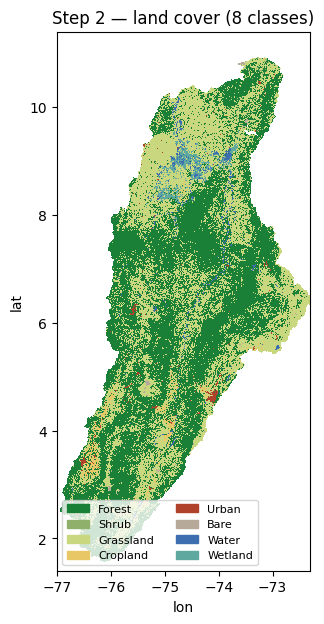

In [3]:
LC_TO_CLASS={10:1,20:2,30:3,40:4,50:5,60:6,70:6,100:6,80:7,90:8,95:8}   # WorldCover code -> class id
CLASS_NAME={1:'Forest',2:'Shrub',3:'Grassland',4:'Cropland',5:'Urban',6:'Bare',7:'Water',8:'Wetland'}
CLASS_COL ={1:'#1a7f37',2:'#8FB06B',3:'#C9D77E',4:'#E8C766',5:'#B0412B',6:'#B7A99A',7:'#3D6FB0',8:'#5FA8A0'}

wc=np.zeros((H,W),'uint8')
for tn in [n for n in zipfile.ZipFile(LCZIP).namelist() if n.endswith('_Map.tif')]:
    with rasterio.open(f"/vsizip/{LCZIP}/{tn}") as src:
        f=40; th,tw=src.height//f, src.width//f
        arr=src.read(1,out_shape=(th,tw),resampling=RS.mode)
        st=src.transform*Affine.scale(src.width/tw, src.height/th)
    tmp=np.zeros((H,W),'uint8')
    reproject(arr,tmp,src_transform=st,src_crs="EPSG:4326",dst_transform=dst_tr,dst_crs="EPSG:4326",resampling=Resampling.nearest)
    wc=np.where(tmp>0,tmp,wc)
land=np.zeros((H,W),'uint8')
for code_,cls in LC_TO_CLASS.items(): land[wc==code_]=cls

fig,ax=plt.subplots(figsize=(5.2,7))
ax.imshow(np.where(basmask,land,np.nan),extent=extent,cmap=ListedColormap([CLASS_COL[i] for i in range(1,9)]),
          vmin=1,vmax=8,interpolation='none')
ax.legend(handles=[mpatches.Patch(color=CLASS_COL[i],label=CLASS_NAME[i]) for i in range(1,9)],
          loc='lower left',fontsize=8,ncol=2)
ax.set_title('Step 2 — land cover (8 classes)'); ax.set_xlabel('lon'); ax.set_ylabel('lat'); plt.show()

## Step 3 — Soils: IGAC field-survey texture family (SoilGrids only as gap-fill)

**Primary source = IGAC.** We read the pre-built raster `data/processed/soil_family_igac.tif` (produced from the 18
in-basin IGAC department soil surveys downloaded via the ArcGIS REST API). For every UCS polygon we parsed the free-text
soil description (`arcilloso`/`fina` → **Fine**, `franco`/`media`/`limoso` → **Medium**, `arenoso`/`gruesa` → **Coarse**)
and burned the dominant family onto the minibacia grid. IGAC covers **≈86 %** of the basin; the remaining cells are
**gap-filled with SoilGrids** (same USDA triangle, collapsed to the 3 families).

> ⚠️ **Why we switched from SoilGrids to IGAC.** SoilGrids topsoil texture in this basin is **near-uniform** (clay 33±4 %,
> sand 33±4 %, silt 33±3 %) and collapses **~95 % of the basin to "Fine"** — a known artefact of a global 250 m ML model
> where Colombia is sparsely sampled, so it regresses to a smooth clay-loam mean. The **field-mapped IGAC survey** instead
> shows a realistic split (**Coarse ≈18 % · Medium ≈36 % · Fine ≈44 %**), capturing the coarse/medium volcanic-Andean
> soils of Cauca, Huila, Tolima, Caldas and Quindío that SoilGrids erases. The two sources agree on only ~39 % of cells,
> and using SoilGrids would badly over-predict runoff and MUSLE erodibility. The cell below prints both so the choice is
> auditable. *(Notebook 09 derives W<sub>m</sub> and K from IGAC texture + depth + drainage — no SoilGrids pedotransfer.)*

> **How to read the two audit numbers the next cell prints (added 2026-08-19) — the prose above is the correct one.** The cell prints `IGAC soil-texture coverage: 98.1% of basin` and `IGAC vs SoilGrids agreement 47%`. **Neither is an IGAC-alone figure.** `soil_family_igac.tif` is already the **merged** raster — `src/build_soil_layer.py` does `final = np.where(igr > 0, igr, sgf)` before writing it — so 98.1 % is the coverage of *IGAC plus the SoilGrids gap-fill*, and the agreement mask `(soil>0) & (sgf>0)` includes every gap-filled cell, where `soil == sgf` **by construction**, which inflates the agreement. The IGAC-alone numbers are the ones stated in the paragraph above, and `src/build_soil_layer.py` prints them itself at build time: **≈86 % coverage, ~39 % agreement**. Consistency check: if IGAC alone covers *x* of the basin and agrees on 39 % of its own cells, the merged-mask agreement is `[x·0.39 + (0.9806 − x)] / 0.9806`; setting that equal to the printed 0.47 gives *x* = **0.852**, recovering the ~86 % to within a point. The 98.1 % is a correct number about the merged layer, wrongly labelled — and the label lives inside a printed string, so it is corrected here rather than in code, which would force a re-execution.

IGAC soil-texture coverage: 98.1% of basin (rest gap-filled by SoilGrids)
basin soil family (IGAC + fill) %%: {'Coarse': 18.1, 'Medium': 36.0, 'Fine': 43.9}
SoilGrids ALONE would say      %%: {'Coarse': 0.0, 'Medium': 5.1, 'Fine': 94.9}   -> collapses to Fine; IGAC vs SoilGrids agreement 47%


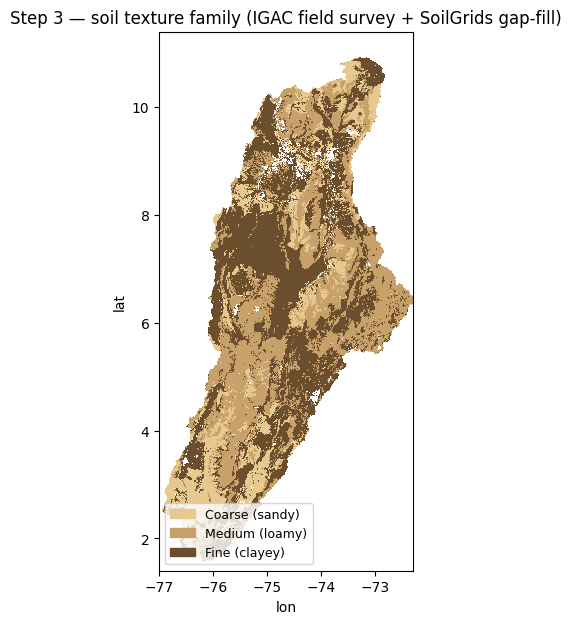

In [4]:
# ---- PRIMARY soil source: IGAC field survey (texture family 1=Coarse 2=Medium 3=Fine), SoilGrids gap-filled ----
IGAC_TIF = REPO/'data'/'processed'/'soil_family_igac.tif'
assert IGAC_TIF.exists(), "build data/processed/soil_family_igac.tif first (merge of IGAC dept surveys + SoilGrids fill)"
soil=np.zeros((H,W),'uint8')
with rasterio.open(IGAC_TIF) as src:
    reproject(rasterio.band(src,1),soil,dst_transform=dst_tr,dst_crs="EPSG:4326",resampling=Resampling.nearest)
SOIL_NAME={1:'Coarse (sandy)',2:'Medium (loamy)',3:'Fine (clayey)'}
SOIL_SHORT={1:'Coarse',2:'Medium',3:'Fine'}; SOIL_COL={1:'#E7C98F',2:'#C7A06A',3:'#6B4E2E'}
FAM={1:'Coarse',2:'Medium',3:'Fine'}

# ---- audit: what SoilGrids ALONE would have said (justifies the switch) ----
def _soil(n):
    with rasterio.open(SOIL+f"/soilgrids_{n}.tif") as src:
        o=np.zeros((H,W),'float32'); reproject(rasterio.band(src,1),o,dst_transform=dst_tr,dst_crs="EPSG:4326",resampling=Resampling.bilinear)
    return o
clay=_soil('clay'); sand=_soil('sand'); silt=_soil('silt')
vs=(clay>0)&(sand>0)&(silt>0)
C=np.where(vs,clay/10.,np.nan); S=np.where(vs,sand/10.,np.nan); Si=np.where(vs,silt/10.,np.nan)
tot=C+S+Si; C,S,Si=C/tot*100,S/tot*100,Si/tot*100          # renormalise to sum 100
conds=[(Si+1.5*C)<15,((Si+1.5*C)>=15)&((Si+2*C)<30),
  (((C>=7)&(C<20)&(S>52)&((Si+2*C)>=30))|((C<7)&(Si<50)&((Si+2*C)>=30))),
  (C>=7)&(C<27)&(Si>=28)&(Si<50)&(S<=52),((Si>=50)&(C>=12)&(C<27))|((Si>=50)&(Si<80)&(C<12)),
  (Si>=80)&(C<12),(C>=20)&(C<35)&(Si<28)&(S>45),(C>=27)&(C<40)&(S>20)&(S<=45),
  (C>=27)&(C<40)&(S<=20),(C>=35)&(S>45),(C>=40)&(Si>=40),(C>=40)&(S<=45)&(Si<40)]
usda=np.select(conds,list(range(1,13)),default=0).astype('uint8')
U2F={1:1,2:1,3:1,4:2,5:2,6:2,7:2,8:3,9:3,10:3,11:3,12:3}     # USDA 12-class -> 3 families
sgf=np.zeros((H,W),'uint8')
for u,f in U2F.items(): sgf[usda==u]=f

bas=subs>0
print('IGAC soil-texture coverage: %.1f%% of basin (rest gap-filled by SoilGrids)'%(100*np.mean(soil[bas]>0)))
print('basin soil family (IGAC + fill) %%:', {FAM[k]:round(100*float(np.mean(soil[bas]==k)),1) for k in (1,2,3)})
m=(soil>0)&(sgf>0)&bas
print('SoilGrids ALONE would say      %%:', {FAM[k]:round(100*float(np.mean(sgf[m]==k)),1) for k in (1,2,3)},
      '  -> collapses to Fine; IGAC vs SoilGrids agreement %.0f%%'%(100*np.mean(soil[m]==sgf[m])))

fig,ax=plt.subplots(figsize=(5.2,7))
ax.imshow(np.where(bas&(soil>0),soil,np.nan),extent=extent,cmap=ListedColormap([SOIL_COL[i] for i in (1,2,3)]),vmin=1,vmax=3,interpolation='none')
ax.legend(handles=[mpatches.Patch(color=SOIL_COL[i],label=SOIL_NAME[i]) for i in (1,2,3)],loc='lower left',fontsize=9)
ax.set_title('Step 3 — soil texture family (IGAC field survey + SoilGrids gap-fill)'); ax.set_xlabel('lon'); ax.set_ylabel('lat'); plt.show()

## Step 4 — URH = soil × land cover, and the fraction table

The **URH id = soil_family·10 + land_class** (e.g. 23 = Medium soil + Grassland). For every minibacia we compute the
**area fraction of each URH** — the numbers the water balance uses. We export the full table and show the basin-wide mix.

> **Disclosure (added 2026-08-19) — this step drops cells and renormalises, and that is where a support difference downstream comes from.** The mask is `valid = basmask & (soil>0) & (land>0)`, and the fractions are then divided by their own row sum, so **every row of `urh_fractions.csv` sums to exactly 1.0 whatever was dropped**. Measured: `(soil>0) & basin` keeps **463,251 of 472,438** basin cells = **98.055 %**, so ~**1.945 %** of the basin (soil nodata) is discarded and its area redistributed pro rata over the surviving URHs. Nothing is printed about it here and the QA cell does not mention it either — which is also why the family shares printed in step 3 total 98.0 %, not 100 %. **Downstream, this is why two correct basin areas disagree:** `minibacias.csv` sums to **257,096.93 km²** while the URH-side table sums to **251,723.51 km²**, and 257,096.93 × 0.98055 = 252,096.6 km², i.e. within **0.15 %** of it (the residual is that the dropped cells are not uniform in latitude). `src/mgb_sediment.py`, `docs/43`, `docs/46` and `docs/51` all handle this correctly as *a correct quantity on a different support* — but it is created here, by one undisclosed line, and it is disclosed here now.

URH table: 8672 minibacias x 24 URH types  -> data/processed/urh_fractions.csv


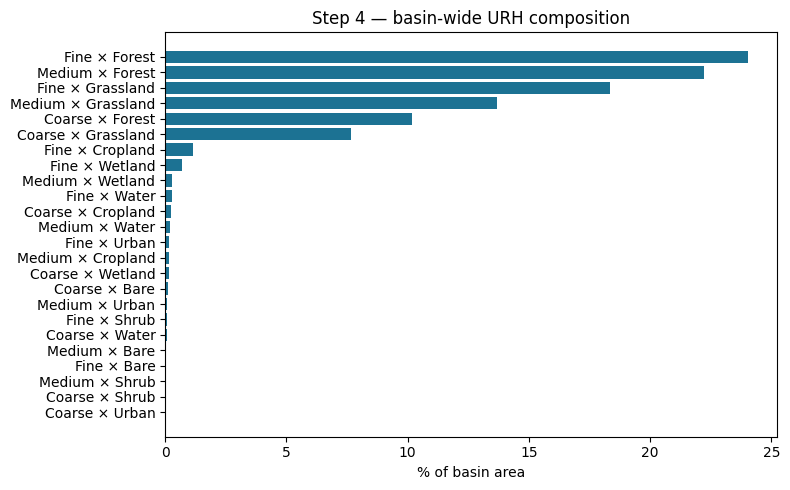

In [5]:
valid=basmask&(soil>0)&(land>0)
urh=(soil.astype('int')*10+land.astype('int'))
df=pd.DataFrame({'mini':subs[valid],'urh':urh[valid]}); df=df[df.mini>0]
comp=df.groupby(['mini','urh']).size().unstack(fill_value=0)
frac=comp.div(comp.sum(1),axis=0)                                   # fraction of each URH per minibacia
proc=REPO/'data'/'processed'; proc.mkdir(parents=True,exist_ok=True)
frac.to_csv(proc/'urh_fractions.csv')
print(f'URH table: {frac.shape[0]} minibacias x {frac.shape[1]} URH types  -> data/processed/urh_fractions.csv')

# basin-wide URH composition
def label(u): return f"{SOIL_SHORT[u//10]} × {CLASS_NAME[u%10]}"
share=(df.urh.value_counts(normalize=True)*100).sort_values(ascending=True)
fig,ax=plt.subplots(figsize=(8,5))
ax.barh([label(u) for u in share.index],share.values,color='#1C7293')
ax.set_xlabel('% of basin area'); ax.set_title('Step 4 — basin-wide URH composition'); plt.tight_layout(); plt.show()

## QA & conclusion

- Land cover (8 classes) and soils (3 IGAC texture families) are on the minibacia grid, masked to the basin.
- The **URH fraction table** (`data/processed/urh_fractions.csv`) gives, per minibacia, the area share of each
  soil×land-cover unit — exactly what MGB needs.

**Notes.** At the preview `SCALE=8` land cover is majority-sampled, so fragmented cropland is under-represented; the
mix ~~sharpens at `SCALE=1`~~ **— RETIRED 2026-08-19, shown not quoted as current: there is no `SCALE=1` run and none is planned; this grid is the adopted Phase A discretisation. The cropland under-representation is therefore not a preview artefact that will go away — it is a property of the shipped table, and `src/nbgen/make_nb12.py` later reports it as *Cropland URHs total 1.4 % of basin area … implausibly low … a resampling artefact rather than a measurement*. This notebook creates that artefact and prints no numbers for the mix, so it is invisible at the point it is made.** WorldCover is 2021 (assumed ~static over 2011–2018). Soil families come from the IGAC field
survey (≈86 % coverage, SoilGrids gap-fill elsewhere); W<sub>m</sub> and K (notebook 09) come from the **same** IGAC
descriptions (texture + depth + drainage), not SoilGrids.

**Next — notebook 09:** derive **W<sub>m</sub>** (available-water capacity × IGAC soil depth) and **K** (USLE-K by
texture with tropical values, adjusted by IGAC drainage) **entirely from IGAC**, validate K against the sediment rating
curves — **RETIRED 2026-08-19, shown not quoted as current: notebook 09 does not do this.** Notebook 09 §5 says in as many words that it *deliberately does not try to validate K against the observed sediment at this stage*; the rating-curve check that once lived there was removed at commit `9a3810c` (2026-07-30), and its measured result was **Pearson r(upstream K, log a) = 0.05 over n = 28 gauges, verdict INCONCLUSIVE (confounders dominate)** — not a validation, and not a refutation of K either. What notebook 09 actually delivers is a value-plausibility check against published texture-class ranges. It does export the per-minibacia parameter table. Then **Phase B:** the MGB-SA water balance → discharge, calibrated
on the IDEAM stations.

**Where this ended up (added 2026-08-19).** **Phase B is CLOSED** on the H2E configuration (`F = 0.25931`) at an `r ≈ 0.57` rainfall-input ceiling, and **Phase C is COMPLETE**: the frozen sediment configuration reproduces the model-free observed ENSO contrast on **18 of 18** stations at a median rate ratio of **3.05×** (range 1.62–4.85, robust across β and both window pairs — `docs/56`), against 22 of 22 observed station-ratios at a median of ~3–5× (`docs/34`). The URH table written above is an input to all of it. One caution that belongs on this table specifically: `docs/42` §3.1–§3.2 shows that the C level, the LS level, the K unit system, the volume convention, P and FG are **seven ways of writing one product Π** (design matrix condition number `inf`), so nothing downstream ever validated the land-class C values this reclassification implies — a fit determines Π, not the pieces.